<img src="../logoutn.jpg" align="right" width="150" /> 

#### Teoría de Circuitos II

# Trabajo semanal 2

Autor: *Farcy Facundo*


In [3]:
# Módulos externos

import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

# módulo de SciPy
from scipy import signal as sig

# Esta parte de código la agregamos SOLO en los notebooks para fijar el estilo de los gráficos.
fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi
fig_font_size = 13

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

In [4]:

from pytc2.sistemas_lineales import analyze_sys, bodePlot, pzmap, pretty_print_bicuad_omegayq
from pytc2.general import print_latex, a_equal_b_latex_s


## Ítems 1 y 2 + Bonus 1 y 2

In [2]:
from IPython.display import IFrame
IFrame("./TS2.pdf", width=1000, height=1000)


### Ejercicio 3
Para corroborar en python simulo la siguiente función hallada en el ejercicio 2:

\begin{equation}
H(s) = \frac{s\frac{\omega_0}{Q}}{s^2+s\frac{\omega_0}{Q}+\omega_0^2}.
\end{equation}

que con los componentes normalizados (y sus respectivas normalizaciones) quedaría:
\begin{equation}
H(s) = \frac{s'\frac{1}{R'*C'}}{(s')^2+s'\frac{1}{R'*C'}+\frac{r4'}{r1'*r3'*r5'*c2'*c'}}*(1+r4')
\end{equation}
\begin{equation}
 c'=c2'=r3'=r5'=1,\quad R'=20,\quad r1'=r4'=2-1\quad \ohm_Y = 2*10^{-4}\pi\frac{1}{\ohm},\quad \ohm_\omega = 2*10^{4}\pi\frac{1}{s}
\end{equation}




Al simular con python...

In [114]:
# Comienzo de la simulación
oh_w=2e4*np.pi;
oh_y=10e-9*2e4*np.pi

r=0;r1=1;r3=2;r4=3;r5=4
res=[20.,1.,1.,1.,1.]
c=0;c2=1
cap=[1.,1.]

res=np.array(res);
cap=np.array(cap);

# Cargamos la funcion transferencia como vectores de sus coeficientes.
num = np.array([1./(res[r]*cap[c])*(1.+res[r4]/res[r5]),0.]);
den = np.array([ 1., 1/(res[r]*cap[c]), res[r4]/(res[r1]*res[r3]*res[r4]*cap[c2])*1/cap[c]])
H1 = sig.TransferFunction( num, den )
#Desnormalizo
res=res/oh_y
cap=cap*oh_y/oh_w
num_des = np.array([ 1/(res[r]*cap[c]) *(1+res[r4]/res[r5]), 0.] )
den_des = np.array([ 1., 1/(res[r]*cap[c]), res[r4]/(res[r1]*res[r3]*res[r4]*cap[c2])*1/cap[c]])
H1_des = sig.TransferFunction( num_des, den_des )
# mostramos la transferencia construida
pretty_print_bicuad_omegayq(num_des,den_des)
#problema: con la función de pretty print me da cualquier cosa el normalizado

<IPython.core.display.Math object>

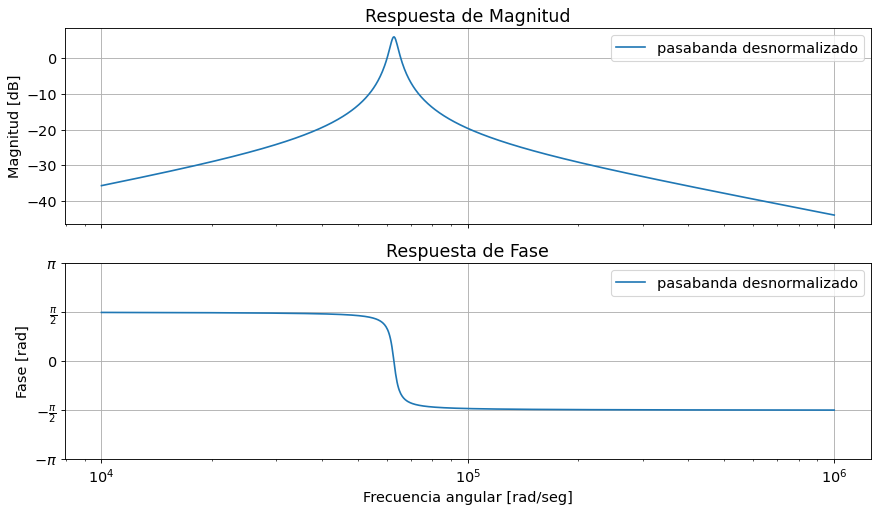

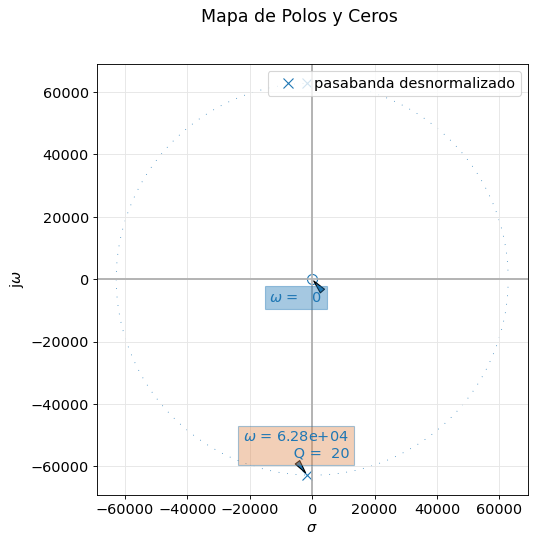

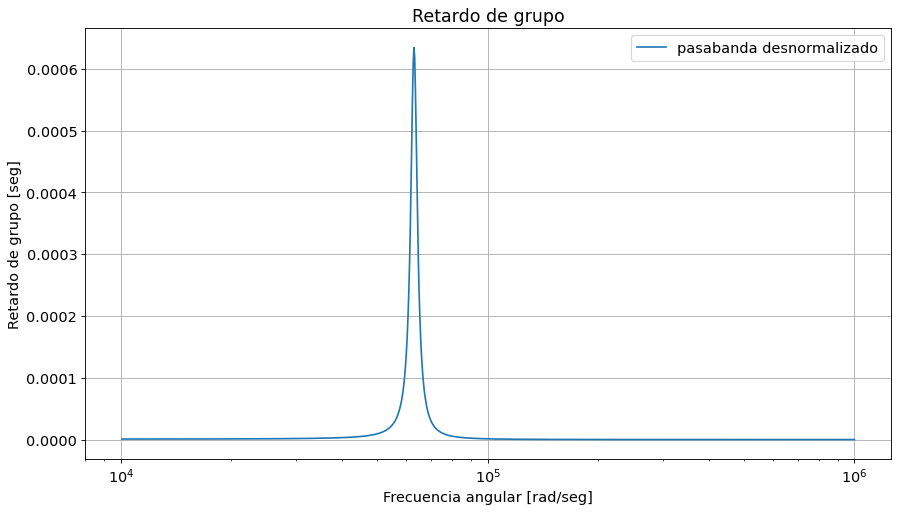

In [115]:
_ = analyze_sys([H1_des], sys_name='pasabanda desnormalizado')

Donde, si se analiza el  diagrama de polos y ceros, se puede ver claramente el Q de los polos de 20, y su correspondiente\begin{equation} \omega_0  = 2*10kHz*pi\end{equation}

###Bonus 3

Finalmente, simulando en LTSPice la transferencia hallada en el ítem 2 (con ganancia k=2), obtenemos lo siguiente:
<img src="./Spice2.png">
<img src="./Spice1.png">


Como se puede observar, con K=2 la banda de paso estaría en aproximadamente 6dB.
Según lo simulado, la frecuencia central no sería exactamente 10kHz, sino 9,98kHz. Puede adjudicarse esto al redondeo realizado al darle valor a los componentes, a la manera en que simula el LTSpice la red circuital o inclusive al error puntos de simulación. Sin embargo, es un resultado más que admisible, con un error de aproximadamente 2%.
Buscando la intersección de |V2/Vin|(f) con 3dB, hallo las frecuencias de corte f1 y f2.
Según la diferencia de cursores, el BW es de 498,44Hz. Esta última, en la transferencia obtenida manualmente se puede ver en el denominador, como wo/Q, que es aproximadamente 3141,5rad/s. Esto, pasado a Hz da efectivamente cercano a lo simulado, en 499,98Hz.
Por último, si realizo la media geométrica entre los f1 y f2 simulados...
\begin{equation}
f0=\sqrt{f1*f2}
\end{equation}
\begin{equation}
f0=\sqrt{10,23kHz*9,73kHz}
\end{equation}
\begin{equation}
f0=10,007kHz
\end{equation}
que nos da lo deseado.